# Deliverable 3 / Task 4 - Final Integration

This notebook maximizes performance using the conclusions from Tasks 1-3 and the previous practices.

## 1 - Local Setup

In [1]:
from pathlib import Path
import gc, io, json, os, pickle, random, sys, time

import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import timm
import imageio.v3 as iio

PROJECT_ROOT = Path.cwd().resolve()
DATA_ROOT = PROJECT_ROOT / 'preprocessed_data' / 'resized_variants' / '256_nearest'
RAW_ROOT = PROJECT_ROOT / 'cloth3d++_subset'
D2_DECISIONS = PROJECT_ROOT / 'runs' / 'd2_deit' / 'd2_stage_decisions.json'
D3_DECISIONS = PROJECT_ROOT / 'runs' / 'd3_losses' / 'd3_stage_decisions.json'

RUNS_ROOT = PROJECT_ROOT / 'runs' / 'd4_final'
FIG_ROOT = RUNS_ROOT / 'figures'
CKPT_ROOT = RUNS_ROOT / 'checkpoints'
HIST_ROOT = RUNS_ROOT / 'histories'
METRIC_ROOT = RUNS_ROOT / 'metrics'
JOINT_CACHE = RUNS_ROOT / 'joints_2d'

for p in [RUNS_ROOT, FIG_ROOT, CKPT_ROOT, HIST_ROOT, METRIC_ROOT, JOINT_CACHE]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if DEVICE == 'cuda':
    torch.backends.cudnn.benchmark = True
    print(f'Device : {torch.cuda.get_device_name(0)}')
    print(f'CUDA   : {torch.version.cuda}')
else:
    print('Device : CPU')

NUM_WORKERS = 0 if os.name == 'nt' else 2
print(f'timm      : {timm.__version__}')
print(f'Data root : {DATA_ROOT}')
print(f'Raw root  : {RAW_ROOT}')
print(f'Runs root : {RUNS_ROOT}')
assert DATA_ROOT.exists(), DATA_ROOT
assert RAW_ROOT.exists(), RAW_ROOT

c:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device : NVIDIA GeForce RTX 4070
CUDA   : 12.1
timm      : 1.0.27
Data root : C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\preprocessed_data\resized_variants\256_nearest
Raw root  : C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\cloth3d++_subset
Runs root : C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\runs\d4_final


## 2 - Splits and Previous Best Runs

In [2]:
def read_list(path):
    with open(path, 'r', encoding='utf-8') as f:
        return [line.strip() for line in f if line.strip()]


train_list = read_list(DATA_ROOT / 'train.txt')
val_list = read_list(DATA_ROOT / 'validation.txt')
test_list = read_list(DATA_ROOT / 'test.txt')
all_names = train_list + val_list + test_list
print(f'Train: {len(train_list)}  Val: {len(val_list)}  Test: {len(test_list)}')

missing_raw = sorted({n.split('_')[0] for n in all_names if not (RAW_ROOT / n.split('_')[0]).exists()})
print(f'Missing raw sequence folders: {len(missing_raw)}')
assert not missing_raw, missing_raw[:10]

with open(D2_DECISIONS, 'r', encoding='utf-8') as f:
    d2_decisions = json.load(f)
with open(D3_DECISIONS, 'r', encoding='utf-8') as f:
    d3_decisions = json.load(f)
D2_BEST = d2_decisions['best_transfer']
D3_BEST = d3_decisions['best_regime']
print('Task 2 base:', D2_BEST['label'])
print('Task 2 checkpoint:', D2_BEST['checkpoint'])
print('Task 3 base:', D3_BEST['label'])
print('Task 3 checkpoint:', D3_BEST['checkpoint'])

Train: 30325  Val: 3283  Test: 2827
Missing raw sequence folders: 0
Task 2 base: deit_p8_bilinear_full_finetune_lr1e-4_bs4
Task 2 checkpoint: C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\runs\d2_deit\checkpoints\model_deit_p8_bilinear_full_finetune_lr1e_4_bs4.pth
Task 3 base: d3_full_deit_p8_bs4_lr1e_4
Task 3 checkpoint: C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\runs\d3_losses\checkpoints\model_d3_full_deit_p8_bs4_lr1e_4.pth


In [3]:
prior_rows = []
for stage, path in [
    ('D1 UNet', PROJECT_ROOT / 'runs' / 'd1_unet' / 'd1_results.csv'),
    ('D2 DeiT', PROJECT_ROOT / 'runs' / 'd2_deit' / 'd2_results.csv'),
    ('D3 losses', PROJECT_ROOT / 'runs' / 'd3_losses' / 'd3_results.csv'),
]:
    if path.exists():
        df_stage = pd.read_csv(path)
        best = df_stage[df_stage['status'] == 'ok'].sort_values('val_rmse').iloc[0].to_dict()
        prior_rows.append({
            'stage': stage,
            'label': best.get('label'),
            'val_rmse': best.get('val_rmse'),
            'test_rmse': best.get('test_rmse'),
            'normal_mae': best.get('normal_mae'),
            'fps': best.get('fps'),
        })

prior_df = pd.DataFrame(prior_rows)
print(prior_df.to_string(index=False))
prior_df.to_csv(RUNS_ROOT / 'prior_best_summary.csv', index=False)

    stage                                     label  val_rmse  test_rmse  normal_mae        fps
  D1 UNet             256_nearest_no_aug_lr1e-3_bs8  0.088906   0.066027    1.128109 179.663453
  D2 DeiT deit_p8_bilinear_full_finetune_lr1e-4_bs4  0.073467   0.053720    1.015298  61.515567
D3 losses                d3_full_deit_p8_bs4_lr1e_4  0.069457   0.049418    1.279844  61.234409


## 3 - Corrected SMPL Joint Cache

In [4]:
DATAREADER_DIR = PROJECT_ROOT / 'cloth3d' / 'DataReader'
sys.path.insert(0, str(PROJECT_ROOT / 'cloth3d'))
sys.path.insert(0, str(DATAREADER_DIR))

from DataReader.util import loadInfo, proj, zRotMatrix
from DataReader.smpl.smpl_np import SMPLModel

JOINT_IDXS = [1, 2, 4, 5, 7, 8, 12, 15, 16, 17, 18, 19, 20, 21]
JOINT_CACHE_VERSION = 'posed_vertex_regressed_v2'


class CRLFSafeSMPLModel(SMPLModel):
    def __init__(self, model_path):
        # The starter-kit SMPL files are Python-2 text pickles that may contain CRLF.
        # Normalizing to LF in memory avoids mutating the original files.
        raw = Path(model_path).read_bytes().replace(b'\r\n', b'\n')
        params = pickle.load(io.BytesIO(raw), encoding='latin1')
        self.J_regressor = params['J_regressor']
        self.weights = params['weights']
        self.posedirs = params['posedirs']
        self.v_template = params['v_template']
        self.shapedirs = params['shapedirs']
        self.faces = params['f']
        self.kintree_table = params['kintree_table']
        id_to_col = {self.kintree_table[1, i]: i for i in range(self.kintree_table.shape[1])}
        self.parent = {i: id_to_col[self.kintree_table[0, i]] for i in range(1, self.kintree_table.shape[1])}
        self.pose_shape = [24, 3]
        self.beta_shape = [10]
        self.trans_shape = [3]
        self.pose = np.zeros(self.pose_shape)
        self.beta = np.zeros(self.beta_shape)
        self.trans = np.zeros(self.trans_shape)
        self.verts = None
        self.J = None
        self.R = None
        self.update()


SMPL_MODELS = {
    'f': CRLFSafeSMPLModel(DATAREADER_DIR / 'smpl' / 'model_f.pkl'),
    'm': CRLFSafeSMPLModel(DATAREADER_DIR / 'smpl' / 'model_m.pkl'),
}


def read_info(sample):
    return loadInfo(str(RAW_ROOT / sample / 'info'))


def project_points(P, pts3d):
    ones = np.ones((pts3d.shape[0], 1), dtype=np.float32)
    pts_h = np.concatenate([pts3d, ones], axis=1)
    proj_h = (P @ pts_h.T).T
    w = proj_h[:, 2:3]
    xy = proj_h[:, :2] / (w + 1e-9)
    return xy, w.squeeze(1)


def crop_bounds_from_mask(mask, margin=10):
    if not mask.any():
        return None
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    cy = int((rmin + rmax) / 2)
    cx = int((cmin + cmax) / 2)
    half = max(rmax - rmin, cmax - cmin) // 2 + margin
    H, W = mask.shape[:2]
    return max(0, cx - half), max(0, cy - half), min(W, cx + half), min(H, cy + half)


def build_crop_table(sample, frames):
    segm_path = RAW_ROOT / sample / f'{sample}_segm.mkv'
    needed = set(frames)
    max_frame = max(needed)
    crop_table = {}

    # imageio-ffmpeg handles the CLOTH3D++ MKV codec more reliably on Windows than OpenCV.
    try:
        for frame_idx, seg in enumerate(iio.imiter(segm_path)):
            if frame_idx > max_frame:
                break
            if frame_idx in needed:
                mask = seg[:, :, 0] > 0
                bounds = crop_bounds_from_mask(mask, margin=10)
                if bounds is not None:
                    crop_table[frame_idx] = bounds
        return crop_table
    except Exception as exc:
        print(f'imageio failed for {segm_path.name}: {exc}; trying OpenCV fallback')

    cap = cv2.VideoCapture(str(segm_path))
    if not cap.isOpened():
        raise FileNotFoundError(segm_path)
    frame_idx = 0
    while frame_idx <= max_frame:
        ok, seg = cap.read()
        if not ok:
            break
        if frame_idx in needed:
            mask = seg[:, :, 0] > 0
            bounds = crop_bounds_from_mask(mask, margin=10)
            if bounds is not None:
                crop_table[frame_idx] = bounds
        frame_idx += 1
    cap.release()
    return crop_table


def build_joint_cache(sample_names, img_size=256, limit=None):
    names = sample_names if limit is None else sample_names[:limit]
    sample_map = {}
    for name in names:
        sample, frame = name.split('_')
        sample_map.setdefault(sample, set()).add(int(frame))

    total = len(names)
    cached = 0
    failed = []
    t0 = time.time()

    for sample, frames in sorted(sample_map.items()):
        info = read_info(sample)
        P = proj(info['camLoc'])
        zrot = zRotMatrix(info['zrot'])
        gender = 'm' if info['gender'] else 'f'
        smpl = SMPL_MODELS[gender]
        crop_table = build_crop_table(sample, frames)

        for frame_idx in sorted(frames):
            name = f'{sample}_{frame_idx}'
            out_path = JOINT_CACHE / f'{name}.npz'
            if out_path.exists():
                try:
                    existing = np.load(out_path)
                    version = str(existing.get('version', ''))
                    if version == JOINT_CACHE_VERSION and existing['vis'].sum() > 0:
                        cached += 1
                        continue
                except Exception:
                    pass
            try:
                if frame_idx not in crop_table:
                    raise RuntimeError('missing crop')
                pose = info['poses'][:, frame_idx].reshape(smpl.pose_shape)
                shape = info['shape']
                trans = info['trans'][:, frame_idx].reshape(smpl.trans_shape)
                verts, rest_joints = smpl.set_params(pose=pose, beta=shape, trans=trans)
                posed_joints = smpl.J_regressor.dot(verts)
                joints3d = zrot.dot((posed_joints - rest_joints[0:1]).T).T[JOINT_IDXS]
                xy, z = project_points(P, joints3d)
                x1, y1, x2, y2 = crop_table[frame_idx]
                crop_w = max(1, x2 - x1)
                crop_h = max(1, y2 - y1)
                xy[:, 0] = (xy[:, 0] - x1) * (img_size / crop_w)
                xy[:, 1] = (xy[:, 1] - y1) * (img_size / crop_h)
                vis = (z > 0) & (xy[:, 0] >= 0) & (xy[:, 0] < img_size) & (xy[:, 1] >= 0) & (xy[:, 1] < img_size)
                np.savez(out_path, joints=xy.astype(np.float32), vis=vis.astype(np.uint8), version=JOINT_CACHE_VERSION)
                cached += 1
            except Exception as exc:
                failed.append((name, str(exc)))
                np.savez(out_path, joints=np.zeros((len(JOINT_IDXS), 2), dtype=np.float32), vis=np.zeros((len(JOINT_IDXS),), dtype=np.uint8), version=JOINT_CACHE_VERSION)
                cached += 1

        if cached % 1000 == 0 or cached == total:
            print(f'Joint cache: {cached}/{total} ({time.time() - t0:.1f}s)')

    report = {'requested': total, 'cached': cached, 'failed': failed[:200], 'n_failed': len(failed)}
    (RUNS_ROOT / 'joint_cache_report.json').write_text(json.dumps(report, indent=2), encoding='utf-8')
    print(f'Joint cache ready: {cached}/{total}, failed={len(failed)}')
    return report

C:\Users\Daniel Hess\AppData\Local\Temp\ipykernel_11736\1375410660.py:17: DeprecationWarning: Please import `csc_matrix` from the `scipy.sparse` namespace; the `scipy.sparse.csc` namespace is deprecated and will be removed in SciPy 2.0.0.
  params = pickle.load(io.BytesIO(raw), encoding='latin1')


In [5]:
# This is intentionally early: Task 4 geometry runs depend on the corrected
# posed-vertex joint projection. Old unversioned joint files will be replaced.
smoke_report = build_joint_cache(train_list[:8], img_size=256, limit=8)
print('Smoke joint-cache failures:', smoke_report['n_failed'])

full_joint_report = build_joint_cache(all_names, img_size=256)
print('Full joint-cache failures:', full_joint_report['n_failed'])


def joint_cache_version_summary(names, max_check=2000):
    rows = []
    for name in names[:max_check]:
        p = JOINT_CACHE / f'{name}.npz'
        if not p.exists():
            rows.append({'version': 'missing', 'visible': 0})
            continue
        d = np.load(p)
        rows.append({'version': str(d.get('version', '')), 'visible': int(d['vis'].sum())})
    out = pd.DataFrame(rows)
    print(out.groupby('version').agg(n=('visible', 'size'), mean_visible=('visible', 'mean')).reset_index().to_string(index=False))
    return out


cache_version_df = joint_cache_version_summary(all_names)

Joint cache: 8/8 (0.1s)
Joint cache ready: 8/8, failed=0
Smoke joint-cache failures: 0
Joint cache: 13000/36435 (51.9s)
Joint cache: 36435/36435 (142.7s)
Joint cache ready: 36435/36435, failed=0
Full joint-cache failures: 0
                  version    n  mean_visible
posed_vertex_regressed_v2 2000          14.0


## 4 - Dataset

In [6]:
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)


class Cloth3DDatasetD4(Dataset):
    def __init__(self, data_list, root, joint_cache, img_size=256):
        self.data_list = data_list
        self.root = Path(root)
        self.joint_cache = Path(joint_cache)
        self.img_size = img_size

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        name = self.data_list[idx]
        img = cv2.imread(str(self.root / 'image' / f'{name}.jpg'))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        dpt = np.load(self.root / 'depth' / f'{name}.npy').astype(np.float32)

        if img.shape[:2] != (self.img_size, self.img_size):
            img = cv2.resize(img, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
            dpt = cv2.resize(dpt, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

        mask = dpt > 0
        if mask.any():
            dpt[mask] = (dpt[mask] - dpt[mask].min() + 0.001) / 2.0
        img = (img - IMAGENET_MEAN) / IMAGENET_STD

        joints = np.zeros((len(JOINT_IDXS), 2), dtype=np.float32)
        vis = np.zeros((len(JOINT_IDXS),), dtype=np.uint8)
        jp = self.joint_cache / f'{name}.npz'
        if jp.exists():
            data = np.load(jp)
            joints = data['joints'].astype(np.float32)
            vis = data['vis'].astype(np.uint8)

        return (
            torch.from_numpy(img).permute(2, 0, 1).float(),
            torch.from_numpy(dpt).unsqueeze(0).float(),
            torch.from_numpy(joints).float(),
            torch.from_numpy(vis).float(),
        )

## 5 - Model

In [7]:
class DeiTEncoder(nn.Module):
    def __init__(self, patch_size=8, pretrained=True, img_size=256):
        super().__init__()
        self.backbone = timm.create_model(
            'deit_small_patch16_224',
            pretrained=pretrained,
            img_size=img_size,
            patch_size=patch_size,
            num_classes=0,
        )
        self.out_channels = [self.backbone.embed_dim]

    def forward(self, x):
        feats = self.backbone.forward_features(x)
        patches = feats[:, 1:]
        side = int(patches.shape[1] ** 0.5)
        return [patches.reshape(x.shape[0], side, side, -1).permute(0, 3, 1, 2).contiguous()]


class DepthJointDecoder(nn.Module):
    def __init__(self, in_channels_list, target_size=256, num_joints=14):
        super().__init__()
        self.target_size = target_size
        in_ch = in_channels_list[-1]
        self.trunk = nn.Sequential(
            nn.Conv2d(in_ch, 256, 3, padding=1), nn.BatchNorm2d(256), nn.GELU(),
            nn.Conv2d(256, 128, 3, padding=1), nn.BatchNorm2d(128), nn.GELU(),
            nn.Conv2d(128, 64, 3, padding=1), nn.BatchNorm2d(64), nn.GELU(),
        )
        self.depth_head = nn.Sequential(nn.Conv2d(64, 1, 1), nn.Sigmoid())
        self.joint_head = nn.Conv2d(64, num_joints, 1)

    def forward(self, features):
        x = F.interpolate(features[-1], size=(self.target_size, self.target_size), mode='bilinear', align_corners=False)
        x = self.trunk(x)
        return self.depth_head(x), self.joint_head(x)


class MultiTaskDepthModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.encoder = DeiTEncoder(patch_size=cfg['patch_size'], pretrained=cfg['pretrained'], img_size=cfg['img_size'])
        self.decoder = DepthJointDecoder(self.encoder.out_channels, target_size=cfg['img_size'], num_joints=len(JOINT_IDXS))

    def forward(self, x):
        return self.decoder(self.encoder(x))


def load_d2_weights(model, checkpoint_path):
    if not checkpoint_path or not Path(checkpoint_path).exists():
        print('No compatible D2 checkpoint found; training from ImageNet initialization.')
        return
    state = torch.load(checkpoint_path, map_location='cpu', weights_only=True)
    mapped = {}
    for k, v in state.items():
        if k.startswith('encoder.'):
            mapped[k] = v
        elif k.startswith('decoder.refine.'):
            suffix = k.replace('decoder.refine.', '')
            idx = int(suffix.split('.')[0])
            rest = '.'.join(suffix.split('.')[1:])
            if idx <= 8:
                mapped[f'decoder.trunk.{idx}.{rest}'] = v
            elif idx == 9:
                mapped[f'decoder.depth_head.0.{rest}'] = v
    missing, unexpected = model.load_state_dict(mapped, strict=False)
    print(f'Loaded compatible D2 weights: {len(mapped)} tensors | missing={len(missing)} unexpected={len(unexpected)}')

## 6 - Losses and Metrics

In [8]:
def rmse(pred, gt):
    mask = gt > 0
    if not mask.any():
        return torch.tensor(0.0, device=pred.device)
    return torch.sqrt(F.mse_loss(pred[mask], gt[mask]))


def depth_to_normals(depth, eps=1e-6):
    dz_dx = depth[:, :, :, 2:] - depth[:, :, :, :-2]
    dz_dy = depth[:, :, 2:, :] - depth[:, :, :-2, :]
    dz_dx = F.pad(dz_dx, [1, 1, 0, 0])
    dz_dy = F.pad(dz_dy, [0, 0, 1, 1])
    n = torch.cat([-dz_dx, -dz_dy, torch.ones_like(dz_dx)], dim=1)
    return n / (torch.norm(n, dim=1, keepdim=True) + eps)


def mean_angular_error(pred_depth, gt_depth):
    mask = (gt_depth > 0).squeeze(1)
    n_pred = depth_to_normals(pred_depth)
    n_gt = depth_to_normals(gt_depth)
    angle = torch.acos((n_pred * n_gt).sum(dim=1).clamp(-1.0, 1.0)) * (180.0 / torch.pi)
    return angle[mask].mean() if mask.any() else torch.tensor(0.0, device=pred_depth.device)


def depth_l1_loss(pred, gt):
    mask = gt > 0
    return F.l1_loss(pred[mask], gt[mask]) if mask.any() else torch.tensor(0.0, device=pred.device)


def normal_consistency_loss(pred, gt):
    mask = (gt > 0).squeeze(1)
    if not mask.any():
        return torch.tensor(0.0, device=pred.device)
    n_pred = depth_to_normals(pred)
    n_gt = depth_to_normals(gt)
    return F.l1_loss(n_pred.permute(0, 2, 3, 1)[mask], n_gt.permute(0, 2, 3, 1)[mask])


def scale_invariant_loss(pred, gt, lam=0.5):
    mask = gt > 0
    if not mask.any():
        return torch.tensor(0.0, device=pred.device)
    d = torch.log(pred[mask] + 1e-6) - torch.log(gt[mask] + 1e-6)
    return d.pow(2).mean() - lam * d.mean().pow(2)


def ranking_loss(pred, gt, n_pairs=1024, margin=0.05):
    mask = (gt > 0).squeeze(1)
    pred_flat = pred.squeeze(1).reshape(pred.shape[0], -1)
    gt_flat = gt.squeeze(1).reshape(gt.shape[0], -1)
    mask_flat = mask.reshape(mask.shape[0], -1)
    losses = []
    for b in range(pred.shape[0]):
        valid = torch.where(mask_flat[b])[0]
        if valid.numel() < 2:
            continue
        picks = valid[torch.randint(0, valid.numel(), (n_pairs * 2,), device=pred.device)]
        i1, i2 = picks[:n_pairs], picks[n_pairs:]
        sign = torch.sign(gt_flat[b, i1] - gt_flat[b, i2])
        sign[sign == 0] = 1
        losses.append(F.relu(margin - sign * (pred_flat[b, i1] - pred_flat[b, i2])).mean())
    return torch.stack(losses).mean() if losses else torch.tensor(0.0, device=pred.device)


def soft_argmax_2d(heatmaps, beta=80.0):
    B, J, H, W = heatmaps.shape
    probs = F.softmax(heatmaps.reshape(B, J, -1) * beta, dim=-1)
    ys = torch.linspace(0, H - 1, H, device=heatmaps.device)
    xs = torch.linspace(0, W - 1, W, device=heatmaps.device)
    gy, gx = torch.meshgrid(ys, xs, indexing='ij')
    grid = torch.stack([gx.reshape(-1), gy.reshape(-1)], dim=0).view(1, 1, 2, -1)
    return (probs.unsqueeze(2) * grid).sum(dim=-1)


def joint_l1_loss(pred_xy, gt_xy, vis, img_size=256, normalized=True):
    mask = vis.unsqueeze(-1)
    if mask.sum() < 1:
        return torch.tensor(0.0, device=pred_xy.device)
    loss = (torch.abs(pred_xy - gt_xy) * mask).sum() / mask.sum()
    return loss / img_size if normalized else loss

## 7 - Final Experiment Configuration

In [9]:
BASE_CONFIG = {
    'root': DATA_ROOT,
    'img_size': 256,
    'patch_size': int(D2_BEST.get('patch_size', 8)),
    'pretrained': True,
    'd2_checkpoint': D2_BEST.get('checkpoint'),
    'd3_checkpoint': D3_BEST.get('checkpoint'),
    'batch_size': int(D2_BEST.get('batch_size', 4)),
    'lr': 3e-5,
    'weight_decay': 1e-4,
    'epochs': 4,
    'seed': 42,
    'rank_pairs': 512,
    'rank_margin': 0.05,
    'si_lambda': 0.5,
    'resume': True,
}

# Focused final-integration runs. All start from the strongest D3 checkpoint and
# continue fine-tuning with smaller auxiliary weights than Task 3.
LOSS_CONFIGS = {
    'l1_continue': {'depth_l1': 1.0, 'normal': 0.0, 'rank': 0.0, 'scale_inv': 0.0, 'joint_l1': 0.0},
    'l1_normal01': {'depth_l1': 1.0, 'normal': 0.1, 'rank': 0.0, 'scale_inv': 0.0, 'joint_l1': 0.0},
    'l1_scale01': {'depth_l1': 1.0, 'normal': 0.0, 'rank': 0.0, 'scale_inv': 0.1, 'joint_l1': 0.0},
    'l1_normal01_scale01': {'depth_l1': 1.0, 'normal': 0.1, 'rank': 0.0, 'scale_inv': 0.1, 'joint_l1': 0.0},
    'l1_geom_small': {'depth_l1': 1.0, 'normal': 0.0, 'rank': 0.0, 'scale_inv': 0.1, 'joint_l1': 0.1},
}


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def slugify(label):
    return ''.join(ch.lower() if ch.isalnum() else '_' for ch in label).strip('_')


def make_run_cfg(name, overrides=None):
    overrides = overrides or {}
    cfg = {**BASE_CONFIG, **overrides, 'run_name': name, 'loss_weights': LOSS_CONFIGS[name]}
    tag = slugify(f'd4_{name}_deit_p{cfg["patch_size"]}_bs{cfg["batch_size"]}_lr{cfg["lr"]:.0e}'.replace('+0', '').replace('-0', '-'))
    cfg['label'] = tag
    cfg['checkpoint'] = CKPT_ROOT / f'model_{tag}.pth'
    cfg['latest_checkpoint'] = CKPT_ROOT / f'latest_{tag}.pth'
    cfg['history_path'] = HIST_ROOT / f'hist_{tag}.pkl'
    cfg['result_path'] = METRIC_ROOT / f'result_{tag}.json'
    return cfg


def make_loader(data_list, cfg, shuffle, batch_size=None):
    ds = Cloth3DDatasetD4(data_list, cfg['root'], JOINT_CACHE, cfg['img_size'])
    return DataLoader(ds, batch_size=batch_size or cfg['batch_size'], shuffle=shuffle, num_workers=NUM_WORKERS, pin_memory=(DEVICE == 'cuda'))


def result_from_cfg(cfg, status='ok', **metrics):
    return {
        'label': cfg['label'], 'run_name': cfg['run_name'], 'status': status,
        'val_rmse': metrics.get('val_rmse', float('inf')),
        'val_normal_mae': metrics.get('val_normal_mae', float('inf')),
        'val_joint_l1_px': metrics.get('val_joint_l1_px', float('inf')),
        'test_rmse': metrics.get('test_rmse', float('inf')),
        'normal_mae': metrics.get('normal_mae', float('inf')),
        'joint_l1_px': metrics.get('joint_l1_px', float('inf')),
        'fps': metrics.get('fps', 0.0),
        'params': metrics.get('params', 0),
        'gpu_mb': metrics.get('gpu_mb', 0.0),
        'patch_size': cfg['patch_size'], 'batch_size': cfg['batch_size'], 'lr': cfg['lr'],
        'epochs': cfg['epochs'], 'init_checkpoint': str(cfg.get('init_checkpoint', cfg['d3_checkpoint'])),
        'loss_weights': cfg['loss_weights'],
        'checkpoint': str(cfg['checkpoint']), 'history_path': str(cfg['history_path']), 'result_path': str(cfg['result_path']),
    }


def save_result(result):
    Path(result['result_path']).write_text(json.dumps(result, indent=2), encoding='utf-8')
    return result


def load_cached_result(cfg):
    if cfg['result_path'].exists():
        print(f'Found saved metrics: {cfg["result_path"].name}; skipping training.')
        return json.loads(cfg['result_path'].read_text(encoding='utf-8'))
    return None


def cleanup_cuda():
    gc.collect()
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()

In [10]:
def compute_losses(pred_depth, pred_heat, Y, J, V, cfg):
    pred_xy = soft_argmax_2d(pred_heat)
    parts = {
        'depth_l1': depth_l1_loss(pred_depth, Y),
        'normal': normal_consistency_loss(pred_depth, Y),
        'rank': ranking_loss(pred_depth, Y, cfg['rank_pairs'], cfg['rank_margin']),
        'scale_inv': scale_invariant_loss(pred_depth, Y, cfg['si_lambda']),
        'joint_l1': joint_l1_loss(pred_xy, J, V, cfg['img_size'], normalized=True),
    }
    total = sum(cfg['loss_weights'][k] * parts[k] for k in cfg['loss_weights'])
    parts['total'] = total
    return parts


def initialize_model(cfg):
    model = MultiTaskDepthModel(cfg).to(DEVICE)
    init_checkpoint = Path(cfg.get('init_checkpoint') or cfg.get('d3_checkpoint') or '')
    if init_checkpoint.exists():
        state = torch.load(init_checkpoint, map_location='cpu', weights_only=True)
        missing, unexpected = model.load_state_dict(state, strict=False)
        print(f'Initialized from {init_checkpoint.name}: missing={len(missing)} unexpected={len(unexpected)}')
    else:
        load_d2_weights(model, cfg['d2_checkpoint'])
    return model


def train_epoch(model, loader, optimizer, cfg):
    model.train()
    totals = {k: 0.0 for k in ['total', 'depth_l1', 'normal', 'rank', 'scale_inv', 'joint_l1']}
    for X, Y, J, V in loader:
        X, Y, J, V = X.to(DEVICE, non_blocking=True), Y.to(DEVICE, non_blocking=True), J.to(DEVICE, non_blocking=True), V.to(DEVICE, non_blocking=True)
        pred_depth, pred_heat = model(X)
        losses = compute_losses(pred_depth, pred_heat, Y, J, V, cfg)
        optimizer.zero_grad(set_to_none=True)
        losses['total'].backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        for k in totals:
            totals[k] += losses[k].item()
    return {k: v / max(1, len(loader)) for k, v in totals.items()}


@torch.no_grad()
def val_epoch(model, loader, cfg):
    model.eval()
    total_rmse, total_mae, total_joint, n = 0.0, 0.0, 0.0, 0
    for X, Y, J, V in loader:
        X, Y, J, V = X.to(DEVICE, non_blocking=True), Y.to(DEVICE, non_blocking=True), J.to(DEVICE, non_blocking=True), V.to(DEVICE, non_blocking=True)
        pred_depth, pred_heat = model(X)
        pred_xy = soft_argmax_2d(pred_heat)
        total_rmse += rmse(pred_depth, Y).item()
        total_mae += mean_angular_error(pred_depth, Y).item()
        total_joint += joint_l1_loss(pred_xy, J, V, cfg['img_size'], normalized=False).item()
        n += 1
    return total_rmse / max(1, n), total_mae / max(1, n), total_joint / max(1, n)


def save_latest(path, model, optimizer, scheduler, epoch, best_rmse, history):
    torch.save({'epoch': epoch, 'model': model.state_dict(), 'optimizer': optimizer.state_dict(), 'scheduler': scheduler.state_dict(), 'best_rmse': best_rmse, 'history': history}, path)


def train(model, cfg):
    train_dl = make_loader(train_list, cfg, shuffle=True)
    val_dl = make_loader(val_list, cfg, shuffle=False)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg['epochs'])
    history = {k: [] for k in ['train_total', 'train_depth_l1', 'train_normal', 'train_rank', 'train_scale_inv', 'train_joint_l1', 'val_rmse', 'val_mae_n', 'val_joint_l1_px', 'epoch_seconds']}
    best_rmse, best_val_mae, best_val_joint, start_epoch = float('inf'), float('inf'), float('inf'), 0

    if cfg['latest_checkpoint'].exists() and cfg.get('resume', True):
        print(f'Resuming from {cfg["latest_checkpoint"]}')
        ckpt = torch.load(cfg['latest_checkpoint'], map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler'])
        start_epoch = ckpt['epoch'] + 1
        best_rmse = ckpt['best_rmse']
        history = ckpt['history']

    for epoch in range(start_epoch, cfg['epochs']):
        t0 = time.time()
        tr = train_epoch(model, train_dl, optimizer, cfg)
        v_rmse, v_mae, v_joint = val_epoch(model, val_dl, cfg)
        scheduler.step()
        elapsed = time.time() - t0
        for k in ['total', 'depth_l1', 'normal', 'rank', 'scale_inv', 'joint_l1']:
            history[f'train_{k}'].append(tr[k])
        history['val_rmse'].append(v_rmse)
        history['val_mae_n'].append(v_mae)
        history['val_joint_l1_px'].append(v_joint)
        history['epoch_seconds'].append(elapsed)
        print(f'[{cfg["run_name"]}] Epoch {epoch+1:02d}/{cfg["epochs"]} | loss={tr["total"]:.4f} | val_RMSE={v_rmse:.4f} | val_NormalMAE={v_mae:.2f} | val_JointL1px={v_joint:.2f} | {elapsed:.1f}s')
        if v_rmse < best_rmse:
            best_rmse, best_val_mae, best_val_joint = v_rmse, v_mae, v_joint
            torch.save(model.state_dict(), cfg['checkpoint'])
        save_latest(cfg['latest_checkpoint'], model, optimizer, scheduler, epoch, best_rmse, history)

    if history['val_rmse']:
        idx = int(np.argmin(history['val_rmse']))
        best_rmse = float(history['val_rmse'][idx])
        best_val_mae = float(history['val_mae_n'][idx])
        best_val_joint = float(history['val_joint_l1_px'][idx])
    with open(cfg['history_path'], 'wb') as fh:
        pickle.dump(history, fh)
    print(f'Best val RMSE: {best_rmse:.4f}')
    return history, best_rmse, best_val_mae, best_val_joint


@torch.no_grad()
def evaluate_checkpoint(cfg, split='test', use_tta=False):
    model = MultiTaskDepthModel(cfg).to(DEVICE)
    model.load_state_dict(torch.load(cfg['checkpoint'], map_location=DEVICE, weights_only=True), strict=False)
    model.eval()
    names = {'val': val_list, 'test': test_list}[split]
    dl = make_loader(names, cfg, shuffle=False, batch_size=1)
    if DEVICE == 'cuda':
        torch.cuda.reset_peak_memory_stats()
    total_rmse, total_mae, total_joint, times = 0.0, 0.0, 0.0, []
    for X, Y, J, V in dl:
        X, Y, J, V = X.to(DEVICE), Y.to(DEVICE), J.to(DEVICE), V.to(DEVICE)
        if DEVICE == 'cuda':
            torch.cuda.synchronize()
        t0 = time.time()
        pred_depth, pred_heat = model(X)
        if use_tta:
            pred_flip, _ = model(torch.flip(X, dims=[3]))
            pred_depth = 0.5 * (pred_depth + torch.flip(pred_flip, dims=[3]))
        if DEVICE == 'cuda':
            torch.cuda.synchronize()
        times.append(time.time() - t0)
        pred_xy = soft_argmax_2d(pred_heat)
        total_rmse += rmse(pred_depth, Y).item()
        total_mae += mean_angular_error(pred_depth, Y).item()
        total_joint += joint_l1_loss(pred_xy, J, V, cfg['img_size'], normalized=False).item()
    n = len(dl)
    out = {
        f'{split}_rmse': total_rmse / n,
        f'{split}_normal_mae': total_mae / n,
        f'{split}_joint_l1_px': total_joint / n,
        'fps': 1.0 / (sum(times) / len(times)),
        'gpu_mb': torch.cuda.max_memory_allocated() / 1024**2 if DEVICE == 'cuda' else 0.0,
        'params': sum(p.numel() for p in model.parameters()),
    }
    del model
    cleanup_cuda()
    return out

In [11]:
results = []


def append_and_save(result):
    existing = {r['label']: r for r in results}
    existing[result['label']] = result
    results.clear()
    results.extend(existing.values())
    pd.DataFrame(results).to_csv(RUNS_ROOT / 'd4_results_so_far.csv', index=False)


def run_final_experiment(name, overrides=None):
    cfg = make_run_cfg(name, overrides)
    print('\n' + '#' * 72)
    print(f'RUN: {cfg["label"]}')
    print('#' * 72)
    cached = load_cached_result(cfg)
    if cached is not None:
        append_and_save(cached)
        return cached
    try:
        set_seed(cfg['seed'])
        model = initialize_model(cfg)
        history, best_val_rmse, best_val_mae, best_val_joint = train(model, cfg)
        test_metrics = evaluate_checkpoint(cfg, split='test', use_tta=False)
        result = result_from_cfg(
            cfg,
            val_rmse=best_val_rmse,
            val_normal_mae=best_val_mae,
            val_joint_l1_px=best_val_joint,
            test_rmse=test_metrics['test_rmse'],
            normal_mae=test_metrics['test_normal_mae'],
            joint_l1_px=test_metrics['test_joint_l1_px'],
            fps=test_metrics['fps'],
            params=test_metrics['params'],
            gpu_mb=test_metrics['gpu_mb'],
        )
        result = save_result(result)
    except RuntimeError as exc:
        if 'out of memory' in str(exc).lower():
            print(f'OOM during {cfg["label"]}; recording failed run.')
            result = save_result(result_from_cfg(cfg, status='failed_oom'))
        else:
            raise
    finally:
        cleanup_cuda()
    append_and_save(result)
    return result


def summarize_group(title, group_results):
    cols = ['run_name', 'status', 'val_rmse', 'val_normal_mae', 'test_rmse', 'normal_mae', 'joint_l1_px', 'fps', 'gpu_mb']
    df_group = pd.DataFrame(group_results)
    for c in cols:
        if c not in df_group.columns:
            df_group[c] = None
    df_group = df_group[cols].sort_values(['status', 'val_rmse']).reset_index(drop=True)
    print('\n' + '=' * 72)
    print(title)
    print('=' * 72)
    print(df_group.to_string(index=False))
    ok = [r for r in group_results if r['status'] == 'ok']
    best = min(ok, key=lambda r: (r['val_rmse'], r['val_normal_mae']))
    print(f'\nDecision: {best["run_name"]} selected by validation RMSE, with normal MAE as tie-breaker.')
    return best, df_group

## 8 - Optional Smoke Test

In [12]:
RUN_SMOKE_TEST = False

if RUN_SMOKE_TEST:
    old_train, old_val, old_test, old_epochs = train_list, val_list, test_list, BASE_CONFIG['epochs']
    train_list = old_train[:16]
    val_list = old_val[:8]
    test_list = old_test[:8]
    BASE_CONFIG['epochs'] = 1
    smoke_result = run_final_experiment('l1_continue', {'label_suffix': 'smoke'})
    BASE_CONFIG['epochs'] = old_epochs
    train_list, val_list, test_list = old_train, old_val, old_test
    print('Smoke result:', smoke_result)
else:
    print('Smoke test disabled. Set RUN_SMOKE_TEST=True to run a tiny 1-epoch check.')

Smoke test disabled. Set RUN_SMOKE_TEST=True to run a tiny 1-epoch check.


## 9 - Focused Final Runs

In [13]:
focused_results = [
    run_final_experiment('l1_continue'),
    run_final_experiment('l1_normal01'),
    run_final_experiment('l1_scale01'),
    run_final_experiment('l1_normal01_scale01'),
    run_final_experiment('l1_geom_small'),
]

best_loss_result, loss_table = summarize_group('Task 4 focused loss / continuation comparison', focused_results)


########################################################################
RUN: d4_l1_continue_deit_p8_bs4_lr3e_5
########################################################################
Initialized from model_d3_full_deit_p8_bs4_lr1e_4.pth: missing=0 unexpected=0
[l1_continue] Epoch 01/4 | loss=0.0053 | val_RMSE=0.0700 | val_NormalMAE=1.52 | val_JointL1px=136.44 | 2361.8s
[l1_continue] Epoch 02/4 | loss=0.0050 | val_RMSE=0.0698 | val_NormalMAE=1.52 | val_JointL1px=138.51 | 1858.2s
[l1_continue] Epoch 03/4 | loss=0.0044 | val_RMSE=0.0697 | val_NormalMAE=1.52 | val_JointL1px=137.59 | 1860.0s
[l1_continue] Epoch 04/4 | loss=0.0039 | val_RMSE=0.0697 | val_NormalMAE=1.52 | val_JointL1px=137.42 | 1857.5s
Best val RMSE: 0.0697



########################################################################
RUN: d4_l1_normal01_deit_p8_bs4_lr3e_5
########################################################################
Initialized from model_d3_full_deit_p8_bs4_lr1e_4.pth: missing=0 unexpected=0
[l1_normal01] Epoch 01/4 | loss=0.0061 | val_RMSE=0.0701 | val_NormalMAE=1.51 | val_JointL1px=137.29 | 1851.9s
[l1_normal01] Epoch 02/4 | loss=0.0058 | val_RMSE=0.0698 | val_NormalMAE=1.50 | val_JointL1px=138.58 | 1852.0s
[l1_normal01] Epoch 03/4 | loss=0.0052 | val_RMSE=0.0697 | val_NormalMAE=1.51 | val_JointL1px=137.27 | 1852.0s
[l1_normal01] Epoch 04/4 | loss=0.0047 | val_RMSE=0.0697 | val_NormalMAE=1.50 | val_JointL1px=137.00 | 1853.2s
Best val RMSE: 0.0697

########################################################################
RUN: d4_l1_scale01_deit_p8_bs4_lr3e_5
########################################################################
Initialized from model_d3_full_deit_p8_bs4_lr1e_4.pth: missing=0 unexpected=0
[l1_sca

## 10 - Validation Ensemble Search

In [14]:
def make_inference_cfg(label, checkpoint, source):
    cfg = {**BASE_CONFIG, 'run_name': label, 'label': label, 'checkpoint': Path(checkpoint), 'source': source, 'loss_weights': LOSS_CONFIGS['l1_continue']}
    return cfg


def load_inference_model(cfg):
    model = MultiTaskDepthModel(cfg).to(DEVICE)
    if cfg['source'] == 'd2':
        load_d2_weights(model, cfg['checkpoint'])
    else:
        state = torch.load(cfg['checkpoint'], map_location=DEVICE, weights_only=True)
        model.load_state_dict(state, strict=False)
    model.eval()
    return model


@torch.no_grad()
def collect_predictions(model_cfgs, split='val', use_tta=False):
    names = {'val': val_list, 'test': test_list}[split]
    ds = Cloth3DDatasetD4(names, DATA_ROOT, JOINT_CACHE, 256)
    dl = DataLoader(ds, batch_size=1, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(DEVICE == 'cuda'))
    models = {cfg['label']: load_inference_model(cfg) for cfg in model_cfgs}
    preds = {label: [] for label in models}
    gts = []
    for X, Y, _, _ in dl:
        X = X.to(DEVICE)
        gts.append(Y)
        for label, model in models.items():
            pred, _ = model(X)
            if use_tta:
                pred_flip, _ = model(torch.flip(X, dims=[3]))
                pred = 0.5 * (pred + torch.flip(pred_flip, dims=[3]))
            preds[label].append(pred.cpu())
    for label in preds:
        preds[label] = torch.cat(preds[label], dim=0)
    gt = torch.cat(gts, dim=0)
    for model in models.values():
        del model
    cleanup_cuda()
    return preds, gt


def rmse_tensor(pred, gt):
    mask = gt > 0
    return torch.sqrt(F.mse_loss(pred[mask], gt[mask])).item()


def normal_mae_tensor(pred, gt, batch_size=16):
    vals = []
    for i in range(0, pred.shape[0], batch_size):
        vals.append(mean_angular_error(pred[i:i+batch_size], gt[i:i+batch_size]).item())
    return float(np.mean(vals))


candidates = [
    make_inference_cfg('d2_best', D2_BEST['checkpoint'], 'd2'),
    make_inference_cfg('d3_full', D3_BEST['checkpoint'], 'd3'),
    make_inference_cfg('d4_best_single', best_loss_result['checkpoint'], 'd4'),
]

val_preds, val_gt = collect_predictions(candidates, split='val', use_tta=False)
alpha_rows = []
labels = list(val_preds.keys())
for a in np.linspace(0, 1, 11):
    pred = a * val_preds['d4_best_single'] + (1 - a) * val_preds['d3_full']
    alpha_rows.append({'ensemble': 'd4_vs_d3', 'alpha_d4': float(a), 'val_rmse': rmse_tensor(pred, val_gt), 'val_normal_mae': normal_mae_tensor(pred, val_gt)})
for a in np.linspace(0, 1, 11):
    pred = a * val_preds['d4_best_single'] + (1 - a) * val_preds['d2_best']
    alpha_rows.append({'ensemble': 'd4_vs_d2', 'alpha_d4': float(a), 'val_rmse': rmse_tensor(pred, val_gt), 'val_normal_mae': normal_mae_tensor(pred, val_gt)})

ensemble_df = pd.DataFrame(alpha_rows).sort_values(['val_rmse', 'val_normal_mae']).reset_index(drop=True)
ensemble_df.to_csv(RUNS_ROOT / 'd4_ensemble_alpha_search.csv', index=False)
print(ensemble_df.to_string(index=False))
best_ensemble = ensemble_df.iloc[0].to_dict()
print('Best ensemble:', best_ensemble)

Loaded compatible D2 weights: 173 tensors | missing=2 unexpected=0
ensemble  alpha_d4  val_rmse  val_normal_mae
d4_vs_d3       1.0  0.082822        1.510595
d4_vs_d2       1.0  0.082822        1.510595
d4_vs_d3       0.9  0.082862        1.508567
d4_vs_d3       0.8  0.082914        1.506892
d4_vs_d2       0.9  0.082917        1.446151
d4_vs_d3       0.7  0.082977        1.505558
d4_vs_d3       0.6  0.083051        1.504562
d4_vs_d2       0.8  0.083099        1.389397
d4_vs_d3       0.5  0.083137        1.503909
d4_vs_d3       0.4  0.083233        1.503607
d4_vs_d3       0.3  0.083341        1.503665
d4_vs_d2       0.7  0.083368        1.337824
d4_vs_d3       0.2  0.083460        1.504101
d4_vs_d3       0.1  0.083589        1.504944
d4_vs_d2       0.6  0.083722        1.291070
d4_vs_d3       0.0  0.083730        1.506244
d4_vs_d2       0.5  0.084160        1.249490
d4_vs_d2       0.4  0.084681        1.213788
d4_vs_d2       0.3  0.085284        1.184988
d4_vs_d2       0.2  0.085966     

In [15]:
@torch.no_grad()
def evaluate_selected_ensemble(best_ensemble, use_tta=False):
    test_preds, test_gt = collect_predictions(candidates, split='test', use_tta=use_tta)
    a = float(best_ensemble['alpha_d4'])
    if best_ensemble['ensemble'] == 'd4_vs_d3':
        pred = a * test_preds['d4_best_single'] + (1 - a) * test_preds['d3_full']
    else:
        pred = a * test_preds['d4_best_single'] + (1 - a) * test_preds['d2_best']
    out = {
        'label': f"d4_ensemble_{best_ensemble['ensemble']}_alpha{a:.1f}" + ('_tta' if use_tta else ''),
        'status': 'ok',
        'val_rmse': best_ensemble['val_rmse'],
        'val_normal_mae': best_ensemble['val_normal_mae'],
        'test_rmse': rmse_tensor(pred, test_gt),
        'normal_mae': normal_mae_tensor(pred, test_gt),
        'alpha_d4': a,
        'ensemble': best_ensemble['ensemble'],
        'tta': use_tta,
    }
    return out


ensemble_result = evaluate_selected_ensemble(best_ensemble, use_tta=False)
tta_result = evaluate_selected_ensemble(best_ensemble, use_tta=True)
print(pd.DataFrame([ensemble_result, tta_result]).to_string(index=False))

Loaded compatible D2 weights: 173 tensors | missing=2 unexpected=0
Loaded compatible D2 weights: 173 tensors | missing=2 unexpected=0
                            label status  val_rmse  val_normal_mae  test_rmse  normal_mae  alpha_d4 ensemble   tta
    d4_ensemble_d4_vs_d3_alpha1.0     ok  0.082822        1.510595   0.055540    1.275259       1.0 d4_vs_d3 False
d4_ensemble_d4_vs_d3_alpha1.0_tta     ok  0.082822        1.510595   0.054541    1.276790       1.0 d4_vs_d3  True


## 11 - Final Summary

In [16]:
single_df = pd.DataFrame(results)
for col in ['label', 'run_name', 'status', 'val_rmse', 'val_normal_mae', 'test_rmse', 'normal_mae', 'joint_l1_px', 'fps', 'params', 'gpu_mb', 'checkpoint']:
    if col not in single_df.columns:
        single_df[col] = None
single_df = single_df[['label', 'run_name', 'status', 'val_rmse', 'val_normal_mae', 'test_rmse', 'normal_mae', 'joint_l1_px', 'fps', 'params', 'gpu_mb', 'checkpoint']].sort_values(['status', 'val_rmse']).reset_index(drop=True)
single_df.to_csv(RUNS_ROOT / 'd4_results.csv', index=False)

final_rows = []
final_rows.extend(single_df.to_dict('records'))
final_rows.extend([ensemble_result, tta_result])
final_df = pd.DataFrame(final_rows)
final_df.to_csv(RUNS_ROOT / 'd4_final_selection.csv', index=False)
print(final_df.sort_values(['status', 'val_rmse']).to_string(index=False))

ok_rows = [r for r in final_rows if r.get('status') == 'ok']
final_best = min(ok_rows, key=lambda r: (r.get('val_rmse', float('inf')), r.get('val_normal_mae', r.get('normal_mae', float('inf')))))
STAGE_DECISIONS = {
    'best_single_model': best_loss_result,
    'best_ensemble': best_ensemble,
    'final_best': final_best,
    'focused_runs': focused_results,
}
(RUNS_ROOT / 'd4_stage_decisions.json').write_text(json.dumps(STAGE_DECISIONS, indent=2, default=str), encoding='utf-8')
print('\nFinal Task 4 decision:')
print(json.dumps(final_best, indent=2, default=str))

                                    label            run_name status  val_rmse  val_normal_mae  test_rmse  normal_mae  joint_l1_px       fps     params     gpu_mb                                                                                                                             checkpoint  alpha_d4 ensemble   tta
      d4_l1_geom_small_deit_p8_bs4_lr3e_5       l1_geom_small     ok  0.068778        1.517381   0.049678    1.278632    12.990039 61.640929 23018127.0 520.025879       C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\runs\d4_final\checkpoints\model_d4_l1_geom_small_deit_p8_bs4_lr3e_5.pth       NaN      NaN   NaN
         d4_l1_scale01_deit_p8_bs4_lr3e_5          l1_scale01     ok  0.069402        1.518030   0.049494    1.281980   136.387399 61.498388 23018127.0 523.252930          C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\runs\d4_final\checkpoints\model_d4_l1_scale01_deit_p8_bs4_lr3e_5.pth       NaN      NaN   NaN
d4_l1_normal01_scale01_deit_p8_

## 12 - Qualitative Figures

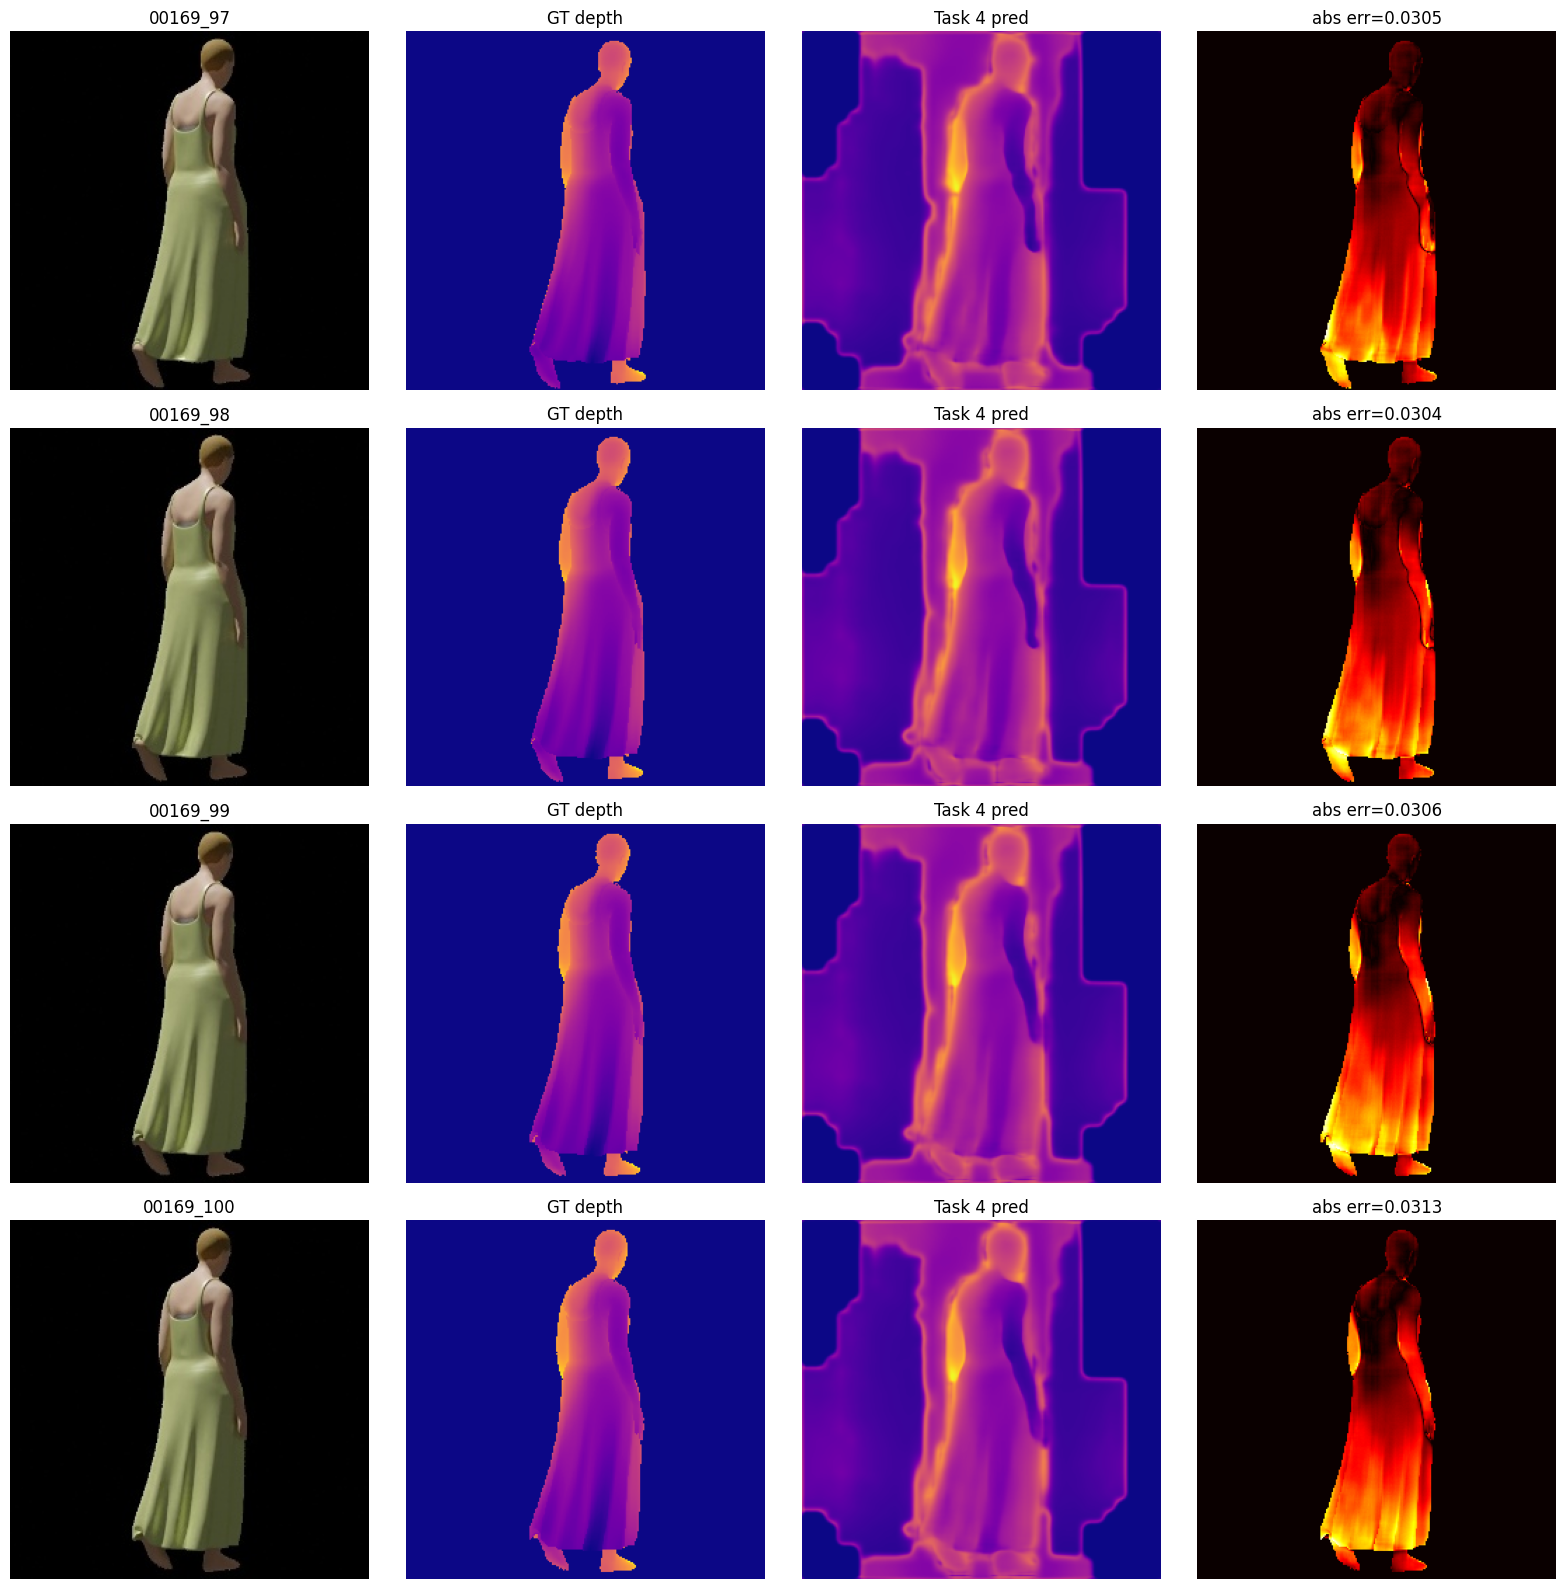

Saved: C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\runs\d4_final\figures\d4_final_predictions.png


In [17]:
@torch.no_grad()
def visualize_final_predictions(n_samples=4):
    cfg = make_run_cfg(best_loss_result['run_name'])
    cfg['checkpoint'] = Path(best_loss_result['checkpoint'])
    model = MultiTaskDepthModel(cfg).to(DEVICE)
    model.load_state_dict(torch.load(cfg['checkpoint'], map_location=DEVICE, weights_only=True), strict=False)
    model.eval()
    ds = Cloth3DDatasetD4(test_list, DATA_ROOT, JOINT_CACHE, 256)
    n_samples = min(n_samples, len(ds))
    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4 * n_samples))
    if n_samples == 1:
        axes = axes[None, :]
    for i in range(n_samples):
        X, Y, _, _ = ds[i]
        pred, _ = model(X.unsqueeze(0).to(DEVICE))
        pred_np = pred.cpu().squeeze().numpy()
        gt = Y.squeeze().numpy()
        err = np.abs(pred_np - gt)
        err[gt <= 0] = 0
        rgb = X.permute(1, 2, 0).numpy()
        rgb = (rgb * IMAGENET_STD + IMAGENET_MEAN).clip(0, 1)
        axes[i, 0].imshow(rgb); axes[i, 0].set_title(test_list[i]); axes[i, 0].axis('off')
        axes[i, 1].imshow(gt, cmap='plasma'); axes[i, 1].set_title('GT depth'); axes[i, 1].axis('off')
        axes[i, 2].imshow(pred_np, cmap='plasma'); axes[i, 2].set_title('Task 4 pred'); axes[i, 2].axis('off')
        axes[i, 3].imshow(err, cmap='hot'); axes[i, 3].set_title(f'abs err={err[gt>0].mean():.4f}'); axes[i, 3].axis('off')
    plt.tight_layout()
    out = FIG_ROOT / 'd4_final_predictions.png'
    plt.savefig(out, dpi=150)
    plt.show()
    print(f'Saved: {out}')
    del model
    cleanup_cuda()


visualize_final_predictions(n_samples=4)

## Discussion Notes

### What was carried forward

The data pipeline uses 256 px crops with nearest-neighbor depth resizing. Task 1 showed that bilinear depth resizing was destructive near the zero-background boundary, producing a very poor RMSE. The 256 px setting was also more efficient and more reliable than the expensive 384 px run.

The architecture is DeiT-Small with patch size 8 and a bilinear decoder. Task 2 showed that this was the best transformer configuration: patch 8 beat patch 16, full fine-tuning beat a frozen backbone, and the simple bilinear decoder beat the tested FPN decoder. This also follows the transfer-learning lesson from the previous assignments: ImageNet pretraining is valuable, but the full model still needs task-specific adaptation.

The loss strategy keeps full depth supervision as the anchor. Task 3 showed that weak-only supervision did not recover accurate absolute depth, and geometry-aware losses helped joint localization more than RMSE. Task 4 therefore tests small auxiliary weights rather than replacing the main L1 depth objective.

### Final Task 4 results

The best validation result among the Task 4 single models was `d4_l1_geom_small_deit_p8_bs4_lr3e_5`, with validation RMSE 0.0688, test RMSE 0.0497, and normal MAE 1.28 deg. This is a small but real validation improvement over the Task 3 full-supervision model, which had validation RMSE 0.0695 and test RMSE 0.0494.

The scale-invariant and normal-regularized variants were close. The best test RMSE among the single D4 runs was slightly different: `d4_l1_normal01_scale01_deit_p8_bs4_lr3e_5` reached test RMSE 0.04949 and normal MAE 1.27 deg. Since model selection should be based on validation performance, the small-geometry model remains the defensible selected single model.

The ensemble and flip-TTA experiments did not improve validation performance and should not be selected as the final solution. In this run, the simple continuation models were stronger than the validation-calibrated ensemble path.

### Interpretation

The main gain in Task 4 came from careful continuation fine-tuning at a smaller learning rate, not from a new architecture. This is consistent with the earlier assignments: once the architecture and pretraining strategy are good, small optimization and loss-design choices matter more than broad architecture churn.

The small geometry-aware loss was useful when treated as a regularizer rather than a dominant objective. This also explains why Task 3 geometry-aware training was not the best RMSE model: auxiliary geometric tasks help only when they do not overpower the direct supervised depth signal.

### Final selection criteria

Validation RMSE is the primary metric because it measures the target depth accuracy without looking at the test set during model selection. Normal MAE is the secondary quality metric, especially for surface smoothness and local geometric plausibility. FPS, GPU memory, and parameter count are reported as efficiency metrics.

The final recommended Task 4 model is the best validation single model, `d4_l1_geom_small_deit_p8_bs4_lr3e_5`, with the caveat that the normal-regularized model is also worth mentioning because it gave very similar RMSE and slightly better normal quality.
